In [2]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import sklearn.model_selection
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
!pip install obspy

In [ ]:
import tarfile

with tarfile.open('dataset8k_v4.tar.xz') as f:
    f.extractall('.')

In [1]:
import tensorflow as tf

# Load the SavedModel
model = tf.keras.models.load_model('./models/4k_v2-20230615T130836Z-001/4k_v2/')


2023-06-18 10:00:00.145877: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-18 10:00:00.192695: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-06-18 10:00:00.401588: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-06-18 10:00:00.402680: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-18 10:00:01.320227: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [ ]:
model.save("./models/model8k_v4_org2")

In [14]:
from obspy.core import read
import obspy
import os
import numpy as np


data_path = './datasets/dataset2k_v1/'
class0_data_path = os.path.join(data_path, 'class0/original')
class1_data_path = os.path.join(data_path, 'class1/original')
class2_data_path = os.path.join(data_path, 'class2/original')
class3_data_path = os.path.join(data_path, 'class3/original')
class4_data_path = os.path.join(data_path, 'class4/original')
class5_data_path = os.path.join(data_path, 'class5/original')
class6_data_path = os.path.join(data_path, 'class6/original')
class7_data_path = os.path.join(data_path, 'class7/original')
class8_data_path = os.path.join(data_path, 'class8/original')


size = 2000
X_train = np.array([])
X_test  = np.array([])
y_train = np.array([])
y_test  = np.array([])

def loadfile(file_data_path):
    if not os.path.isfile(file_data_path):
        return None
    data = np.array([])

    singlechannel = obspy.read(file_data_path)
    data = np.array(singlechannel[0].data)

    # print(data.shape)

    return data

def loadfolder(folder_data_path):
    result_data = np.array([])

    for data_file_name in os.listdir(folder_data_path):
        data_file_path = os.path.join(folder_data_path, data_file_name)
        data = loadfile(data_file_path)
        if len(data) != size:
            continue
        result_data = np.append(result_data, np.array(data))

    x = len(result_data) // size
    result_data = result_data.reshape((x, size))
    return result_data

def reload8k():
    global X_train, X_test, y_train, y_test

    class0_data = loadfolder(class0_data_path)
    print(class0_data.shape)

    class1_data = loadfolder(class1_data_path)
    print(class1_data.shape)

    class2_data = loadfolder(class2_data_path)
    print(class2_data.shape)

    class3_data = loadfolder(class3_data_path)
    print(class3_data.shape)

    class4_data = loadfolder(class4_data_path)
    print(class4_data.shape)

    class5_data = loadfolder(class5_data_path)
    print(class5_data.shape)

    class6_data = loadfolder(class6_data_path)
    print(class6_data.shape)

    class7_data = loadfolder(class7_data_path)
    print(class7_data.shape)

    class8_data = loadfolder(class8_data_path)
    print(class8_data.shape)

    # until = 250 // 5
    # data_01234 = np.concatenate((class0_data[:until], class1_data[:until], class2_data[:until * 2], class3_data[:until]), axis = 0)
    # label_01234 = np.zeros((data_01234.shape[0]))

    # label_01 = np.concatenate((class0_label, class1_label), axis = 0)


    data_78 = np.concatenate((class6_data ,class7_data, class8_data), axis = 0)
    label_78 = np.ones((data_78.shape[0]))

    # until = (len(class0_data) - len(data_5678)) // 16

    # data_1234 = np.concatenate((class2_data[:until], class3_data[:until], class4_data[:until]), axis = 0)
    # label_1234 = np.ones((data_1234.shape[0]))

    # data_p = np.concatenate((data_1234, data_5678), axis = 0)
    # label_p = np.concatenate((label_1234, label_5678), axis = 0)

    # data_0 = data_0[:len(data_p)]
    # label_0 = label_0[:len(label_p)]


    until = len(data_78) // 3

    data_345 = np.concatenate((class3_data[:until], class2_data[:until], class4_data[:until // 2], class0_data[:until // 2]), axis = 0)
    label_345 = np.zeros((data_345.shape[0]))

    X = np.concatenate((data_345, data_78), axis = 0)
    Y = np.concatenate((label_345, label_78), axis = 0)

    # X = np.concatenate((data_0, data_p), axis = 0)
    # Y = np.concatenate((label_0, label_p), axis = 0)

    print("============")
    # print(data_0.shape)
    # print(data_p.shape)
    # print(data_1234.shape)
    # print(data_78.shape)
    print(data_345.shape)
    print(data_78.shape)
    print(X.shape)
    print(Y.shape)


    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, Y, test_size=0.40, random_state=0)

    print("============")
    print(X_train.shape)
    print(X_test.shape)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = reload8k()



(406, 2000)
(574, 2000)
(576, 2000)
(518, 2000)
(398, 2000)
(239, 2000)
(200, 2000)
(106, 2000)
(143, 2000)
(446, 2000)
(449, 2000)
(895, 2000)
(895,)
(537, 2000)
(358, 2000)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

(537, 2000, 1)
(358, 2000, 1)
Epoch 1/65
17/17 [==============================] - 2s 63ms/step - loss: 1332.5350 - accuracy: 0.5289 - val_loss: 51.8519 - val_accuracy: 0.6034
Epoch 2/65
17/17 [==============================] - 1s 53ms/step - loss: 33.4011 - accuracy: 0.5736 - val_loss: 3.0989 - val_accuracy: 0.4693
Epoch 3/65
17/17 [==============================] - 1s 51ms/step - loss: 980.2904 - accuracy: 0.4767 - val_loss: 60.9878 - val_accuracy: 0.2821
Epoch 4/65
17/17 [==============================] - 1s 52ms/step - loss: 101.2252 - accuracy: 0.3706 - val_loss: 18.6630 - val_accuracy: 0.4469
Epoch 5/65
17/17 [==============================] - 1s 53ms/step - loss: 580.4309 - accuracy: 0.5009 - val_loss: 2.6976 - val_accuracy: 0.4944
Epoch 6/65
17/17 [==============================] - 1s 51ms/step - loss: 124.4148 - accuracy: 0.4413 - val_loss: 60.3152 - val_accuracy: 0.3855
Epoch 7/65
17/17 [==============================] - 1s 54ms/step - loss: 152.5417 - accuracy: 0.4358 - val_l

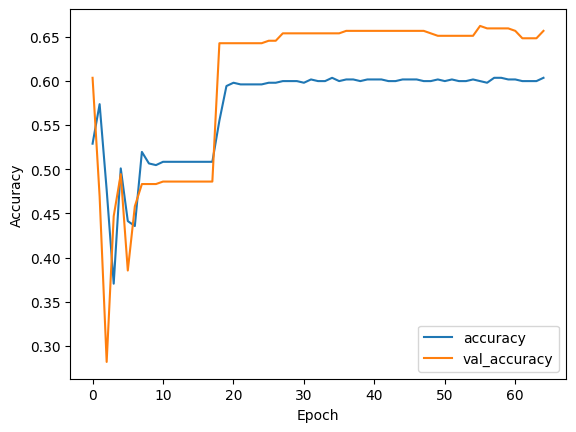

In [15]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

num_epochs = 65

# X_train, X_test, y_train, y_test = reload8k()

divider = 1

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

print(X_train.shape)
print(X_test.shape)


model = models.Sequential(
    [
        layers.Conv1D(128, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(16, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(16, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

(537, 2000, 1)
(358, 2000, 1)
Epoch 1/35
17/17 [==============================] - 5s 248ms/step - loss: 238.7803 - accuracy: 0.5177 - val_loss: 15.4339 - val_accuracy: 0.6620
Epoch 2/35
17/17 [==============================] - 4s 224ms/step - loss: 25.7513 - accuracy: 0.5456 - val_loss: 9.7581 - val_accuracy: 0.7151
Epoch 3/35
17/17 [==============================] - 4s 223ms/step - loss: 9.3292 - accuracy: 0.5233 - val_loss: 2.6975 - val_accuracy: 0.4330
Epoch 4/35
17/17 [==============================] - 4s 218ms/step - loss: 3.0351 - accuracy: 0.4637 - val_loss: 1.4268 - val_accuracy: 0.4497
Epoch 5/35
17/17 [==============================] - 4s 239ms/step - loss: 1.5135 - accuracy: 0.4767 - val_loss: 1.3029 - val_accuracy: 0.4609
Epoch 6/35
17/17 [==============================] - 4s 221ms/step - loss: 1.1265 - accuracy: 0.4842 - val_loss: 1.2454 - val_accuracy: 0.4721
Epoch 7/35
17/17 [==============================] - 4s 217ms/step - loss: 0.9376 - accuracy: 0.4916 - val_loss: 1.

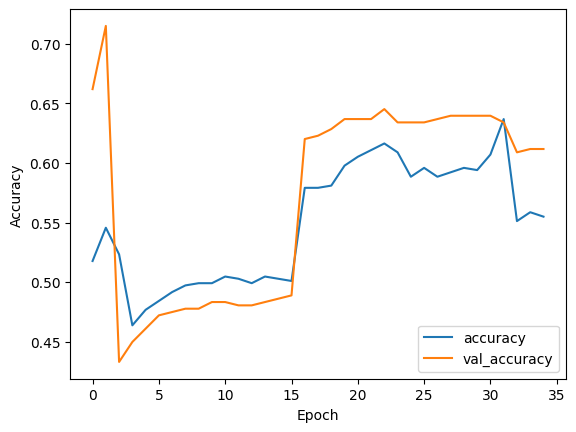

In [16]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


# X_train, X_test, y_train, y_test = reload8k()

divider = 1
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

model = models.Sequential(
    [
        layers.Conv1D(512, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(8, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=35, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


# X_train, X_test, y_train, y_test = reload8k()

# Path: model.ipynb

divider = 1

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

print(X_train.shape)
print(X_test.shape)


model = models.Sequential(
    [
        layers.Conv1D(512, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(8, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        # model.add(LSTM(64)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=35, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score


print(X_test.shape)
y_pred = model.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)
print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [9]:
color_img = cv2.imread('colorscale_jet.jpg')

# color_img = [item for index, item in enumerate(color_img[15]) if index % 5 != 0]

colors = []



for i in range(0,len(color_img[15]), 5):
  colors.append(color_img[15][i])

len(colors)


52

 1 (4000,)


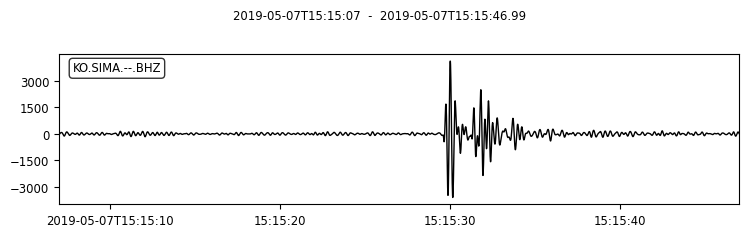

 2 (100,)


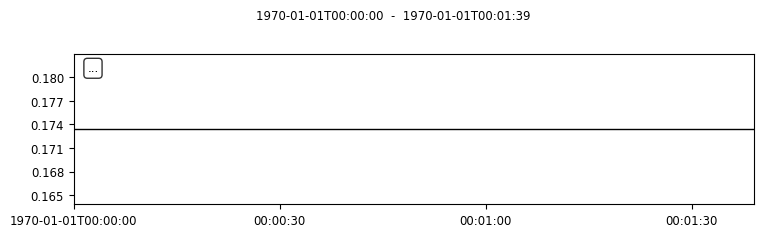

 3 (1, 4000, 1)
 4 -18.539655685424805
1/1 [==============================] - 0s 14ms/step
1.00000, 

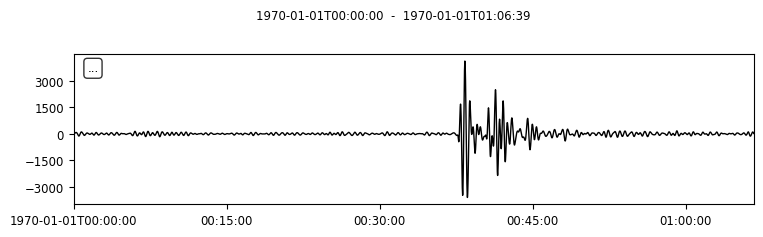

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [12]:
from obspy import read, Trace
import numpy as np

divide_number = 40

# path0 = "./dataset8k_v4/class1/original/201901_10_62__SHUT.BHZ.KO_original.sac"
# trace0 = read(path0)[0]
# print(trace0.data.shape)
# trace0.plot()

# yummydata = np.array(trace0.data[:8000 // divide_number])
# print(len(yummydata))

# path = "./dataset8k_v4/class7/original/201901_17_0__SIMA.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class5/original/201901_24_1__SIMA.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class6/original/201902_1_147__MDNY.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class7/original/201903_9_1__SIMA.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class6/original/201907_13_0__SIMA.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class8/original/201901_1_1__SIMA.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class6/original/201910_18_148__ADVT.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class6/original/201910_6_29__GEDZ.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class6/original/202005_9_0__BALB.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class1/original/201901_11_5__KULA.BHZ.KO_original.sac"
# path = "./dataset8k_v4/class2/original/201901_1_53__ARMT.BHZ.KO_original.sac"


# path = "./dataset8k_v4/class2/clean/201901_1_71_ADVT.BHZ.SAC"
# path = "./dataset8k_v4/class2/clean/201905_4_26_TVSB.BHZ.SAC"
# path = "./dataset8k_v4/class5/clean/201904_15_0_SIMA.BHZ.SAC"
# path = "./dataset8k_v4/class5/clean/201911_25_120_MDNY.BHZ.SAC"
# path = "./dataset8k_v4/class5/clean/202009_11_0_SIMA.BHZ.SAC"
# # path = "./dataset8k_v4/class6/clean/201911_8_0_SIMA.BHZ.SAC"
# # path = "./dataset8k_v4/class6/clean/202105_13_3_SIMA.BHZ.SAC"
# # path = "./dataset8k_v4/class6/clean/202110_7_24_GEDZ.BHZ.SAC"
# # path = "./dataset8k_v4/class7/clean/201912_1_4_SIMA.BHZ.SAC"
# path = "./dataset8k_v4/class7/clean/202010_18_3_SIMA.BHZ.SAC"
# # path = "./dataset8k_v4/class8/clean/201907_10_0_SIMA.BHZ.SAC"
# # path = "./dataset8k_v4/class8/clean/201911_5_5_SIMA.BHZ.SAC"
# # path = "./dataset8k_v4/class8/clean/201912_11_0_BALB.BHZ.SAC"
# # path = "./dataset8k_v4/class8/clean/202010_39_8_SIMA.BHZ.SAC"

path = "./datasets/dataset4k/class5/201905_1_0_SIMA.BHZ.SAC"



trace = read(path)[0]
print(f" 1 {trace.data.shape}")
trace.plot()

avg_num = np.average(trace.data)

avg = np.zeros(4000 // divide_number) + avg_num

tmp = Trace(data = avg)
print(f" 2 {tmp.data.shape}")
tmp.plot()


predict_data = trace.data.reshape((1, len(trace.data), 1))
print(f" 3 {predict_data.shape}")
print(f" 4 {predict_data[0][2][0]}")


t_pred = model.predict(predict_data)
# for y_val in t_pred:
#   print( "%.5f" % float(y_val), end = ", ")

pred_list = []

for i in range(divide_number):
    start_index = i * (len(predict_data[0]) // divide_number)
    end_index = (i + 1) * (len(predict_data[0]) // divide_number)

    # Protect the original data by making a copy
    original_data = predict_data.copy()

    # Replace the section of predict_data with yummydata
    for index in range(len(avg)):
      predict_data[0][index + start_index] = avg[index]
    # predict_data[0][start_index:end_index] = yummydata[:]

    d = np.array([])
    for index in range(len(trace.data)):
      # d.insert(predict_data[0][index][0])
      d = np.append(d, predict_data[0][index][0])

    d.reshape((1, 4000))
    # pl = Trace(data = d)
    # pl.plot()

    # # Perform the prediction on the modified predict_data
    y_pred = model.predict(predict_data)
    for y_val in y_pred[0]:
        print("%.5f" % float(y_val), end=", ")
        pred_list.append(float(y_val))

    # # Restore the original data
    predict_data = original_data.copy()


trace = Trace(data = predict_data[0].flatten())
trace.plot()
trace.plot(outfile='trace_image.png')
print(pred_list)






In [13]:
import cv2
# from google.colab.patches import cv2_imshow

image = cv2.imread('trace_image.png')
overlay = image.copy()

# image sizes
print(overlay.shape)

# Rectangle parameters
x, y, w, h = 80, 60, 680, 150

rect_with_offset = w // divide_number

for i in range(divide_number):
    color_index = (100 - int(pred_list[i] * 100))
    # color_index = color_index
    if t_pred < 0.49:
      color_index = 100 - color_index

    print(color_index)
    b, g, r = colors[color_index // 2]
    # print(b, g ,r)
    # if y_pred > 0.5:
    overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), (int(b), int(g), int(r)), -1)
    # else:
    #     overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), color_list[len(color_list) - color_index], -1)

    # overlay = cv2.putText(overlay, str(i), (x + i * rect_with_offset, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 255), 2, cv2.LINE_AA)
    # overlay = cv2.putText(overlay, str(pred_list[i])[:4], (x + i * rect_with_offset + 30, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2, cv2.LINE_AA)


# A filled rectangle
# cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 200, 0), -1)

alpha = 0.5  # Transparency factor.
# Following line overlays transparent rectangle
# over the image
image_new = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

cv2.imwrite("attention_signal.jpg", image_new)

# cv2_imshow(image_new)
cv2.imshow('Image', image_new)
cv2.waitKey(0)

cv2.destroyAllWindows()

(250, 800, 3)
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = reload8k()

rfc = RandomForestClassifier(max_depth=5, random_state=2)
rfc.fit(X_train, y_train)

# draw confusion matrix
y_pred = rfc.predict(X_test)

print(accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['class2', 'class1'], columns=['class2', 'class1'])
plt.figure(figsize=(5.5,4))
sns.heatmap(cm_df, annot=True)
plt.title('Random Forest \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()



In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = reload8k()

neigh = KNeighborsClassifier(n_neighbors=3)

# decrease dimension
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1]))

neigh.fit(X_train, y_train)

# draw confusion matrix
y_pred = neigh.predict(X_test)
print(accuracy_score(y_test, y_pred))

# display_confusion_matrix(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['class2', 'class1'], columns=['class2', 'class1'])
plt.figure(figsize=(5.5,4))
sns.heatmap(cm_df, annot=True)
plt.title('KNN \nAccuracy:{0:.3f}'.format(accuracy_score(y_test, y_pred)))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


In [ ]:
# Use CNN to train model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt


X_train, X_test, y_train, y_test = reload8k()

# Path: model.ipynb
divider = 1

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))

print(X_train.shape)
print(X_test.shape)

model = models.Sequential(
    [
        layers.Conv1D(1024, 3, activation="relu", input_shape=(X_train.shape[1], X_test.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        layers.Dense(2, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)


model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
# plt.legend(loc='lower right')
plt.show()



In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten


X_train, X_test, y_train, y_test = reload8k()

print(X_train.shape)

# Path: model.ipynb

divider = 1

# X_train = X_train.reshape((X_train.shape[0], X_train.shape[1] // divider, divider))
# X_test = X_test.reshape((X_test.shape[0], X_test.shape[1] // divider , divider))


# Define the model architecture
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[0], divider)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
# model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))


# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten

X_train, X_test, y_train, y_test = reload8k()

# Path: model.ipynb

divider = 1

# Reshape the input data to have the shape (samples, timesteps, features)
timesteps = X_train.shape[1]
features = 1
X_train_reshaped = X_train.reshape((X_train.shape[0], timesteps, features))
X_test_reshaped = X_test.reshape((X_test.shape[0], timesteps, features))

print(X_train_reshaped.shape)

# Define the model architecture
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=10, activation='relu', input_shape=(timesteps, features)))
model.add(MaxPooling1D(pool_size=5))  # Change this line
model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=5))  # Change this line
model.add(Flatten())
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_reshaped, y_train, epochs=10)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")


In [ ]:
import cv2
import numpy as np

# Generate a sample data array
data = np.random.rand(10, 10)

# Normalize the data to [0, 255]
normalized_data = cv2.normalize(data, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Apply the COLORMAP_JET colormap
colormap_image = cv2.applyColorMap(normalized_data, cv2.COLORMAP_JET)

# Display the image
cv2.imshow('COLORMAP_JET', colormap_image)
cv2.waitKey(0)
cv2.destroyAllWindows()